# Food Delivery Analytics & ETA Predictor

## Problem Statement
Zomato/Swiggy ka ek bada challenge hai — delivery time accurately predict karna.
Late deliveries = bad customer experience = customer churn.

## Dataset
- Source: Kaggle (Rajat Kumar)
- 45,593 real delivery records
- 11 features including ratings, vehicle type, order type

## Approach
1. SQL Analysis — Business patterns nikale
2. EDA — Visual insights
3. ML Models — Linear Regression, Random Forest, XGBoost
4. Deployment — Live Streamlit app

## Key Findings
- High rated partners (5-6) deliver 45% faster than low rated (3-4)
- Motorcycle slowest vehicle — 27.6 min average
- Electric scooter fastest — 24.4 min average
- XGBoost best model — RMSE 7.29 min

In [4]:
import pandas as pd
df = pd.read_csv('deliverytime.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(45593, 11)
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle', 'Time_taken(min)']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [5]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()


Shape: (45593, 11)

Missing Values:
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

Basic Stats:


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


## 📊 SQL Analysis
Business patterns nikalne ke liye SQL window functions use kiye.

**Key queries:**
- Vehicle type vs delivery time (GROUP BY)
- Top 10 fastest partners (RANK window function)
- Vehicle-wise average comparison (PARTITION BY)

In [10]:
import sqlite3

# Dataset SQL database mein daalna
conn = sqlite3.connect(':memory:')
df.to_sql('deliveries', conn, index=False)

# Query 1 — Vehicle type vs average delivery time
q1 = pd.read_sql("""
    SELECT Type_of_vehicle,
           ROUND(AVG("Time_taken(min)"), 2) as avg_time,
           COUNT(*) as total_orders
    FROM deliveries
    GROUP BY Type_of_vehicle
    ORDER BY avg_time DESC
""", conn)

print(q1)

     Type_of_vehicle  avg_time  total_orders
0        motorcycle      27.61         26435
1           bicycle      26.43            68
2           scooter      24.48         15276
3  electric_scooter      24.47          3814


In [11]:
# Query 2 — Order type vs delivery time
q2 = pd.read_sql("""
    SELECT Type_of_order,
           ROUND(AVG("Time_taken(min)"), 2) as avg_time,
           COUNT(*) as total_orders
    FROM deliveries
    GROUP BY Type_of_order
    ORDER BY avg_time DESC
""", conn)
print("Order Type Analysis:")
print(q2)

# Query 3 — Partner rating vs delivery time
q3 = pd.read_sql("""
    SELECT 
        ROUND(Delivery_person_Ratings, 0) as rating,
        ROUND(AVG("Time_taken(min)"), 2) as avg_time,
        COUNT(*) as total_orders
    FROM deliveries
    GROUP BY ROUND(Delivery_person_Ratings, 0)
    ORDER BY rating DESC
""", conn)
print("\nRating Analysis:")
print(q3)

# Query 4 — RANK window function 
q4 = pd.read_sql("""
    SELECT 
        Delivery_person_ID,
        ROUND(AVG("Time_taken(min)"), 2) as avg_time,
        COUNT(*) as total_orders,
        RANK() OVER (ORDER BY AVG("Time_taken(min)") ASC) as speed_rank
    FROM deliveries
    GROUP BY Delivery_person_ID
    ORDER BY speed_rank
    LIMIT 10
""", conn)
print("\nTop 10 Fastest Delivery Partners:")
print(q4)

# Query 5 — PARTITION BY window function
q5 = pd.read_sql("""
    SELECT 
        Type_of_vehicle,
        "Time_taken(min)",
        ROUND(AVG("Time_taken(min)") OVER (
            PARTITION BY Type_of_vehicle), 2) as vehicle_avg,
        ROUND("Time_taken(min)" - AVG("Time_taken(min)") OVER (
            PARTITION BY Type_of_vehicle), 2) as diff_from_avg
    FROM deliveries
    LIMIT 10
""", conn)
print("\nPartition By Example:")
print(q5)

Order Type Analysis:
  Type_of_order  avg_time  total_orders
0         Meal      26.42         11458
1        Snack      26.29         11533
2       Buffet      26.28         11280
3       Drinks      26.19         11322

Rating Analysis:
   rating  avg_time  total_orders
0     6.0     23.94            53
1     5.0     24.42         37478
2     4.0     35.02          7801
3     3.0     36.62           223
4     1.0     26.00            38

Top 10 Fastest Delivery Partners:
  Delivery_person_ID  avg_time  total_orders  speed_rank
0      KOLRES06DEL03     19.44             9           1
1      DEHRES20DEL03     19.60            10           2
2      DEHRES17DEL01     19.75            12           3
3      KOLRES01DEL03     19.82            11           4
4      KNPRES01DEL01     20.00            11           5
5      BHPRES15DEL03     20.14             7           6
6     LUDHRES18DEL02     20.20            10           7
7      KOLRES14DEL02     20.62            13           8
8      GO

## 📈 Exploratory Data Analysis
Visual patterns discover kiye — 6 charts banaye.

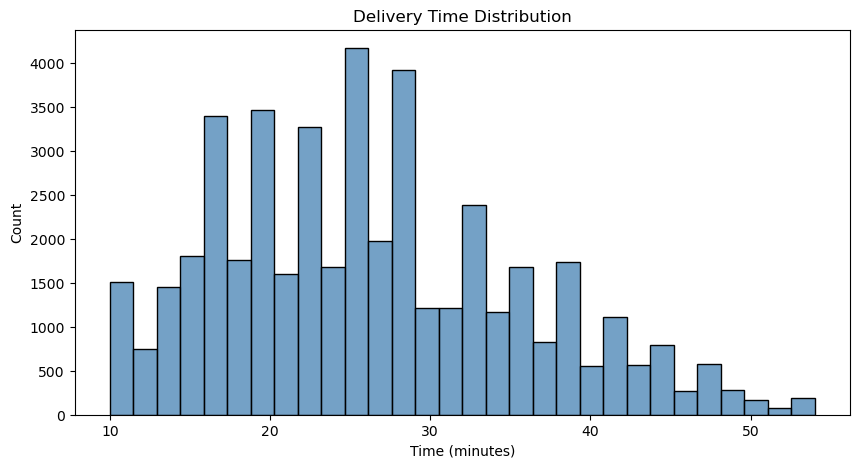

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Delivery time distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Time_taken(min)'], bins=30, color='steelblue')
plt.title('Delivery Time Distribution')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.show()

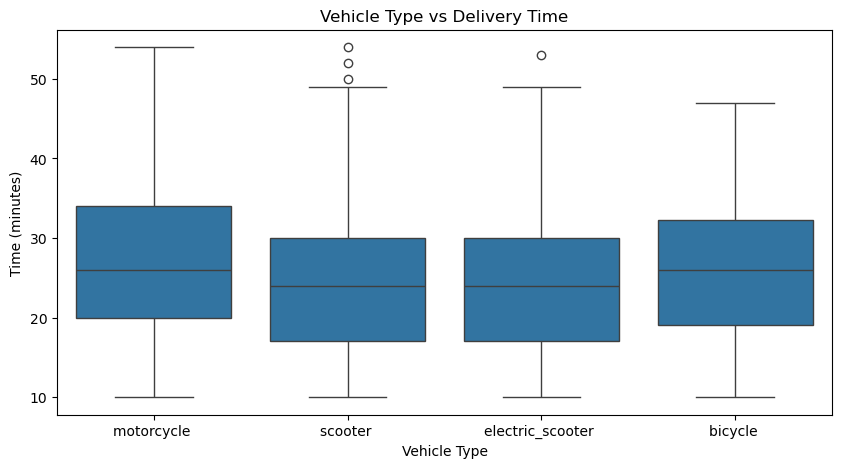

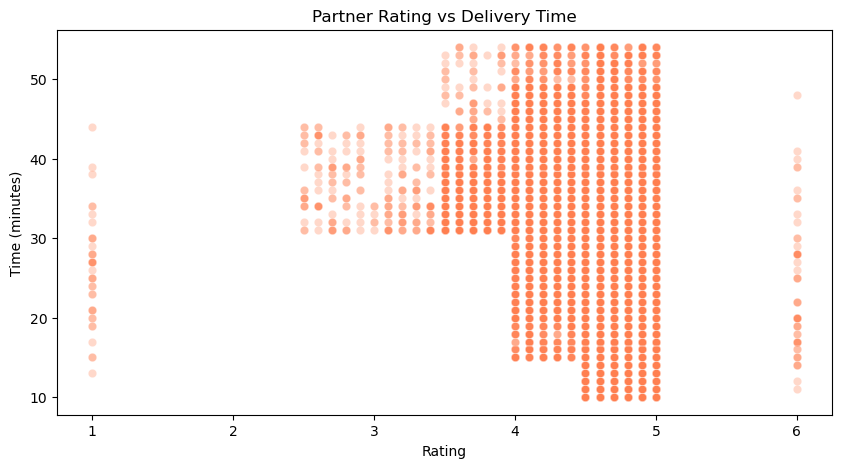

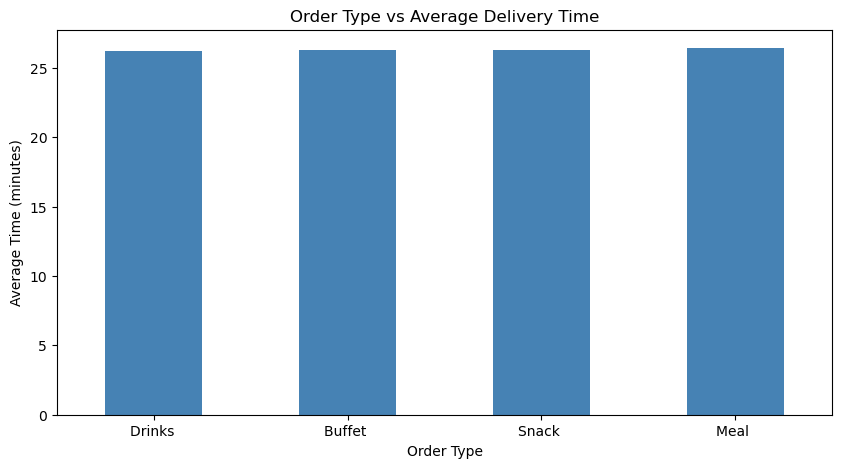

<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

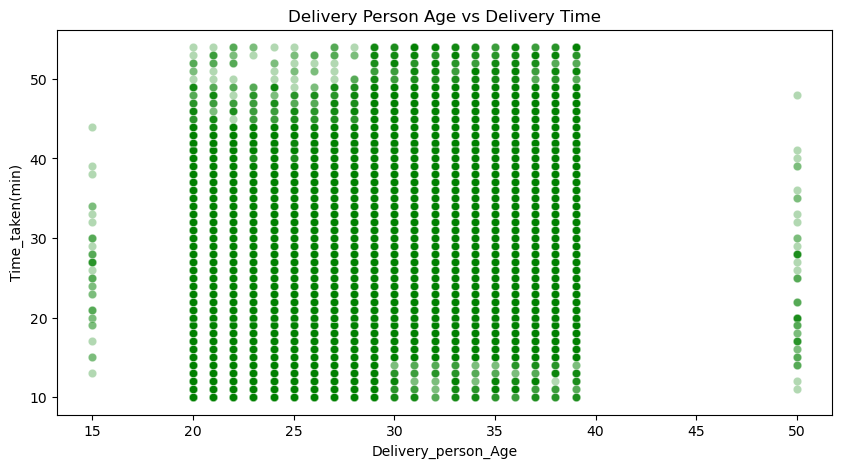

In [8]:
# Chart 2 — Vehicle type vs delivery time
plt.figure(figsize=(10,5))
sns.boxplot(x='Type_of_vehicle', y='Time_taken(min)', data=df)
plt.title('Vehicle Type vs Delivery Time')
plt.xlabel('Vehicle Type')
plt.ylabel('Time (minutes)')
plt.show()

# Chart 3 — Rating vs delivery time
plt.figure(figsize=(10,5))
sns.scatterplot(x='Delivery_person_Ratings', y='Time_taken(min)', 
                data=df, alpha=0.3, color='coral')
plt.title('Partner Rating vs Delivery Time')
plt.xlabel('Rating')
plt.ylabel('Time (minutes)')
plt.show()

# Chart 4 — Order type vs delivery time
plt.figure(figsize=(10,5))
order_avg = df.groupby('Type_of_order')['Time_taken(min)'].mean()
order_avg.sort_values().plot(kind='bar', color='steelblue')
plt.title('Order Type vs Average Delivery Time')
plt.xlabel('Order Type')
plt.ylabel('Average Time (minutes)')
plt.xticks(rotation=0)
plt.show()

# Chart 5 — Age vs delivery time
plt.figure(figsize=(10,5))
sns.scatterplot(x='Delivery_person_Age', y='Time_taken(min)', 
                data=df, alpha=0.3, color='green')
plt.title('Delivery Person Age vs Delivery Time')
plt.xlabel

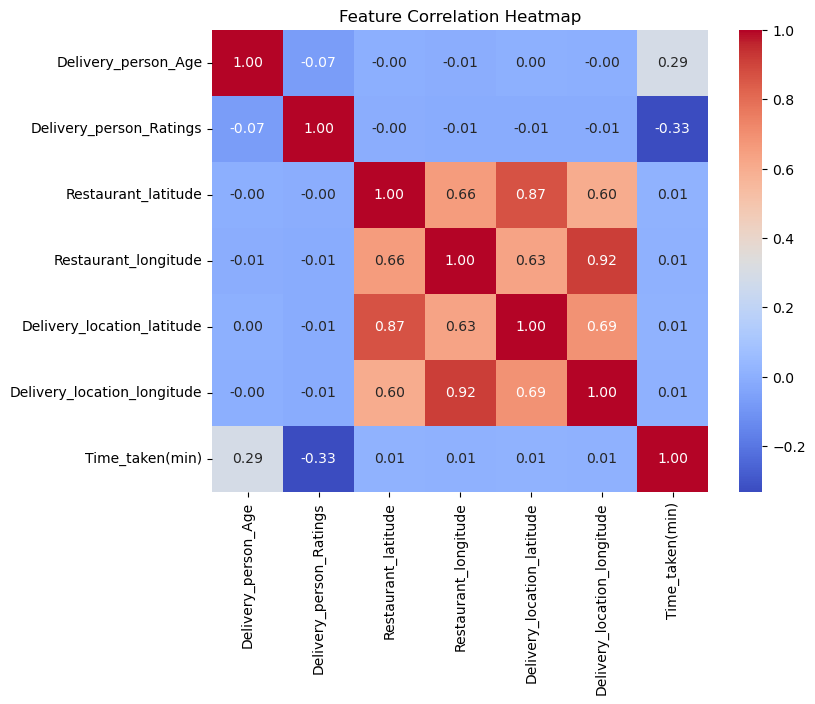

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 🤖 Machine Learning Models
3 models train kiye aur compare kiye:
- Linear Regression (baseline)
- Random Forest
- XGBoost (best performer)

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Categorical columns encode karo
le = LabelEncoder()
df['vehicle_encoded'] = le.fit_transform(df['Type_of_vehicle'])
df['order_encoded'] = le.fit_transform(df['Type_of_order'])

# Features aur target
X = df[['Delivery_person_Age', 'Delivery_person_Ratings',
        'vehicle_encoded', 'order_encoded']]
y = df['Time_taken(min)']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (36474, 4)
Test size: (9119, 4)


In [16]:
!pip install xgboost

In [18]:
from xgboost import XGBRegressor

# 3 models define karo
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# Har model train karo aur compare karo
print("Model Comparison:")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}:")
    print(f"  RMSE = {rmse:.2f} min")
    print(f"  R2   = {r2:.3f}")
    print("-" * 45)

Model Comparison:
---------------------------------------------
Linear Regression:
  RMSE = 8.46 min
  R2   = 0.183
---------------------------------------------
Random Forest:
  RMSE = 8.05 min
  R2   = 0.261
---------------------------------------------
XGBoost:
  RMSE = 7.93 min
  R2   = 0.284
---------------------------------------------


In [19]:
import numpy as np

# Distance calculate karo
df['distance'] = np.sqrt(
    (df['Delivery_location_latitude'] - df['Restaurant_latitude'])**2 +
    (df['Delivery_location_longitude'] - df['Restaurant_longitude'])**2
)

# Updated features
X = df[['Delivery_person_Age', 'Delivery_person_Ratings',
        'vehicle_encoded', 'order_encoded', 'distance']]
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Dobara train karo
print("Updated Model Comparison:")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}:")
    print(f"  RMSE = {rmse:.2f} min")
    print(f"  R2   = {r2:.3f}")
    print("-" * 45)

Updated Model Comparison:
---------------------------------------------
Linear Regression:
  RMSE = 8.46 min
  R2   = 0.183
---------------------------------------------
Random Forest:
  RMSE = 8.07 min
  R2   = 0.258
---------------------------------------------
XGBoost:
  RMSE = 7.29 min
  R2   = 0.395
---------------------------------------------


In [20]:
# Age groups add karo
df['age_group'] = pd.cut(df['Delivery_person_Age'], 
                          bins=[0, 25, 35, 50], 
                          labels=[0, 1, 2])
df['age_group'] = df['age_group'].astype(int)

# Rating bucket
df['high_rated'] = (df['Delivery_person_Ratings'] >= 4.8).astype(int)

# Updated features
X = df[['Delivery_person_Age', 'Delivery_person_Ratings',
        'vehicle_encoded', 'order_encoded', 
        'distance', 'age_group', 'high_rated']]
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Final Model Comparison:")
print("-" * 45)
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}:")
    print(f"  RMSE = {rmse:.2f} min")
    print(f"  R2   = {r2:.3f}")
    print("-" * 45)

Final Model Comparison:
---------------------------------------------
Linear Regression:
  RMSE = 8.43 min
  R2   = 0.190
---------------------------------------------
Random Forest:
  RMSE = 8.07 min
  R2   = 0.258
---------------------------------------------
XGBoost:
  RMSE = 7.29 min
  R2   = 0.395
---------------------------------------------


In [21]:
import pickle

xgb_model = models['XGBoost']
pickle.dump(xgb_model, open('model.pkl', 'wb'))
print("Model saved!")

Model saved!


In [12]:
app_code = '''
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open(r"C:/food delivey project/model.pkl", "rb"))

st.title("Food Delivery Time Predictor")

age = st.slider("Partner Age", 15, 50, 28)
rating = st.slider("Partner Rating", 1.0, 6.0, 4.5)
vehicle = st.selectbox("Vehicle", ["motorcycle","scooter","electric_scooter","bicycle"])
order = st.selectbox("Order Type", ["Meal","Snack","Drinks","Buffet"])
distance = st.slider("Distance", 0.0, 0.5, 0.1)

vehicle_map = {"bicycle":0,"electric_scooter":1,"motorcycle":2,"scooter":3}
order_map = {"Buffet":0,"Drinks":1,"Meal":2,"Snack":3}
age_group = 0 if age<=25 else (1 if age<=35 else 2)
high_rated = 1 if rating>=4.8 else 0

if st.button("Predict"):
    pred = model.predict([[age,rating,vehicle_map[vehicle],order_map[order],distance,age_group,high_rated]])[0]
    st.success(f"Estimated Time: {pred:.0f} minutes")
'''

with open(r"C:/food delivey project/app.py", "w") as f:
    f.write(app_code)
    
print("app.py saved!")

app.py saved!
